In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import dask.dataframe as dd
import os
from glob import glob

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

import matplotlib.transforms as mtransforms

crs = ccrs.PlateCarree()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [2]:
L4_dir = '/home/ref-cmems-public/tac/sea-level'

In [49]:
old_files = sorted(glob(os.path.join(L4_dir, 'SEALEVEL_GLO_PHY_L4_MY_008_047', 'cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.25deg_P1D', '2023', '*', '*')))
old_files
                
               

['/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.25deg_P1D/2023/001/dt_global_allsat_phy_l4_20230101_20231013.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.25deg_P1D/2023/002/dt_global_allsat_phy_l4_20230102_20231013.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.25deg_P1D/2023/003/dt_global_allsat_phy_l4_20230103_20231013.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.25deg_P1D/2023/004/dt_global_allsat_phy_l4_20230104_20231013.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.25deg_P1D/2023/005/dt_global_allsat_phy_l4_20230105_20231013.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy

In [50]:
new_files = sorted(glob(os.path.join(L4_dir, 'SEALEVEL_GLO_PHY_L4_MY_008_047','cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411', '2023','*', '*')))
new_files

['/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411/2023/001/dt_global_allsat_phy_l4_20230101_20241023.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411/2023/002/dt_global_allsat_phy_l4_20230102_20241023.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411/2023/003/dt_global_allsat_phy_l4_20230103_20241023.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411/2023/004/dt_global_allsat_phy_l4_20230104_20241023.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411/2023/005/dt_global_allsat_phy_l4_20230105_20241023.nc',
 '/home/ref-cmems-public/tac/sea-level/SEALEVEL_GL

In [54]:
dso = xr.open_mfdataset(old_files)

In [55]:
dsn = xr.open_mfdataset(new_files)

In [63]:
dso_ = dso.sel(time = slice(pd.to_datetime('2023-03-25'), pd.to_datetime('2023-07-10')), longitude = slice(0, 7), latitude = slice(36, 44))
dsn_ = dsn.sel(time = slice(pd.to_datetime('2023-03-25'), pd.to_datetime('2023-07-10')), longitude = slice(0, 7), latitude = slice(36, 44))

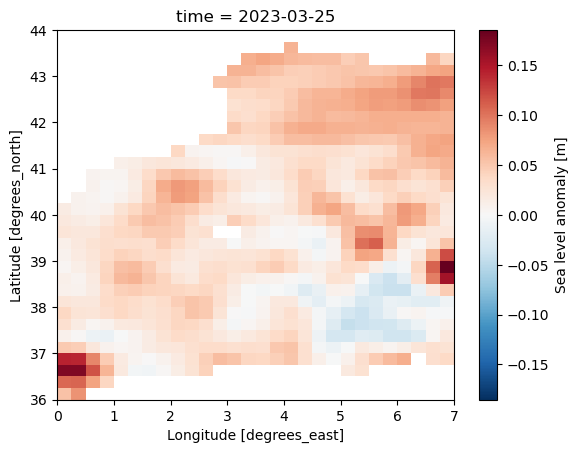

In [64]:
dso_.sla.isel(time=0).plot()

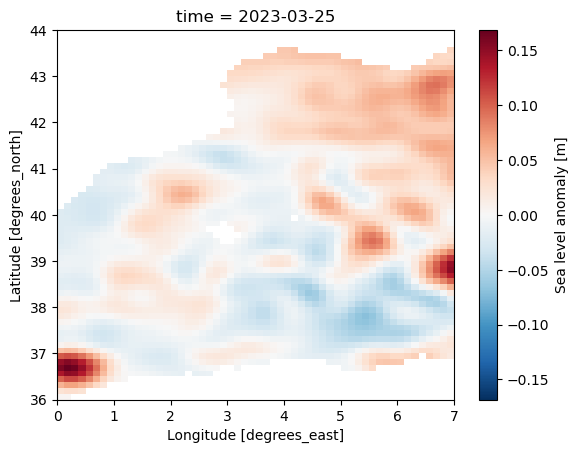

In [65]:
dsn_.sla.isel(time=0).plot()

In [66]:
dsn_

<xarray.Dataset>
Dimensions:         (time: 108, latitude: 64, nv: 2, longitude: 56)
Coordinates:
  * time            (time) datetime64[ns] 2023-03-25 2023-03-26 ... 2023-07-10
  * latitude        (latitude) float32 36.06 36.19 36.31 ... 43.69 43.81 43.94
  * longitude       (longitude) float32 0.0625 0.1875 0.3125 ... 6.812 6.938
  * nv              (nv) int32 0 1
Data variables: (12/14)
    crs             (time) int32 -2147483647 -2147483647 ... -2147483647
    lat_bnds        (time, latitude, nv) float32 dask.array<chunksize=(1, 64, 2), meta=np.ndarray>
    lon_bnds        (time, longitude, nv) float32 dask.array<chunksize=(1, 56, 2), meta=np.ndarray>
    sla             (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    err_sla         (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    ugosa           (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    ...              ...
    err_vgosa       (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    adt             (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    ugos            (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    vgos            (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    flag_ice        (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    tpa_correction  (time) float64 dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/42)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    geospatial_vertical_units:       m
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    time_coverage_end:               2023-01-01T12:00:00Z
    time_coverage_start:             2022-12-31T12:00:00Z
    platform:                        Cryosat-2 New Orbit, Sentinel-3B, Altika...

In [69]:
directory = '/home/datawork-lops-oc/aponte/margot/med_coloc/L4_sealevel'
dso_.to_netcdf(os.path.join(directory,'L4_without_swot.nc'))
dsn_.to_netcdf(os.path.join(directory,'L4_with_swot.nc'))

__________
_________
# NO SWOT

In [ ]:
dir = '/home/ifremer-lops-cswot/DATA/DUACS/NOSWOT/duacs_dt2021'

In [8]:
f = glob(os.path.join('/home/ifremer-lops-cswot/DATA/DUACS/NOSWOT/duacs_dt2021/regional-europe/dt-grids/all-sat-merged/2023', '*.nc'))
ds = xr.open_mfdataset(f).sel(time = slice(pd.to_datetime('2023-03-25'), pd.to_datetime('2023-07-10')), longitude = slice(0, 7), latitude = slice(36, 44))
directory = '/home/datawork-lops-oc/aponte/margot/med_coloc/L4_sealevel'
ds.to_netcdf(os.path.join(directory,'L4_regional_europe_dt_2021_noswot.nc'))

In [12]:
ds

<xarray.Dataset>
Dimensions:         (time: 108, latitude: 64, nv: 2, longitude: 56)
Coordinates:
  * time            (time) datetime64[ns] 2023-03-25 2023-03-26 ... 2023-07-10
  * latitude        (latitude) float32 36.06 36.19 36.31 ... 43.69 43.81 43.94
  * longitude       (longitude) float32 0.0625 0.1875 0.3125 ... 6.812 6.938
  * nv              (nv) int32 0 1
Data variables: (12/14)
    crs             (time) int32 -2147483647 -2147483647 ... -2147483647
    lat_bnds        (time, latitude, nv) float32 dask.array<chunksize=(1, 64, 2), meta=np.ndarray>
    lon_bnds        (time, longitude, nv) float32 dask.array<chunksize=(1, 56, 2), meta=np.ndarray>
    sla             (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    err_sla         (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    ugosa           (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    ...              ...
    err_vgosa       (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    adt             (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    ugos            (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    vgos            (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
    tpa_correction  (time) float64 dask.array<chunksize=(1,), meta=np.ndarray>
    flag_ice        (time, latitude, longitude) float64 dask.array<chunksize=(1, 64, 56), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-4 sea su...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-01-01T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2022-12-31T12:00:00Z
    title:                           DT merged all satellites European Seas G...

In [16]:
f = glob(os.path.join('/home/ifremer-lops-cswot/DATA/DUACS/NOSWOT/duacs_dt2021/global/dt-grids/all-sat-merged/2023', '*.nc'))
ds = xr.open_mfdataset(f).sel(time = slice(pd.to_datetime('2023-03-25'), pd.to_datetime('2023-07-10')), longitude = slice(0, 7), latitude = slice(36, 44))
directory = '/home/datawork-lops-oc/aponte/margot/med_coloc/L4_sealevel'
ds.to_netcdf(os.path.join(directory,'L4_global_dt_2021_noswot.nc'))

In [17]:
ds

<xarray.Dataset>
Dimensions:         (time: 108, latitude: 32, nv: 2, longitude: 28)
Coordinates:
  * time            (time) datetime64[ns] 2023-03-25 2023-03-26 ... 2023-07-10
  * latitude        (latitude) float32 36.12 36.38 36.62 ... 43.38 43.62 43.88
  * longitude       (longitude) float32 0.125 0.375 0.625 ... 6.375 6.625 6.875
  * nv              (nv) int32 0 1
Data variables: (12/14)
    crs             (time) int32 -2147483647 -2147483647 ... -2147483647
    lat_bnds        (time, latitude, nv) float32 dask.array<chunksize=(1, 32, 2), meta=np.ndarray>
    lon_bnds        (time, longitude, nv) float32 dask.array<chunksize=(1, 28, 2), meta=np.ndarray>
    sla             (time, latitude, longitude) float64 dask.array<chunksize=(1, 32, 28), meta=np.ndarray>
    err_sla         (time, latitude, longitude) float64 dask.array<chunksize=(1, 32, 28), meta=np.ndarray>
    ugosa           (time, latitude, longitude) float64 dask.array<chunksize=(1, 32, 28), meta=np.ndarray>
    ...              ...
    err_vgosa       (time, latitude, longitude) float64 dask.array<chunksize=(1, 32, 28), meta=np.ndarray>
    adt             (time, latitude, longitude) float64 dask.array<chunksize=(1, 32, 28), meta=np.ndarray>
    ugos            (time, latitude, longitude) float64 dask.array<chunksize=(1, 32, 28), meta=np.ndarray>
    vgos            (time, latitude, longitude) float64 dask.array<chunksize=(1, 32, 28), meta=np.ndarray>
    tpa_correction  (time) float64 dask.array<chunksize=(1,), meta=np.ndarray>
    flag_ice        (time, latitude, longitude) float64 dask.array<chunksize=(1, 32, 28), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-4 sea su...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-01-01T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2022-12-31T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...